In [16]:
import numpy as np
import pandas as pd
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# load tsv with eval data
df = pd.read_csv(f'eval_tsvs/real_parcellation_cortex_switched.tsv', sep='\t')

In [18]:
custom_palette = {
'random': 'black',
'variance': '#E69F00',
'variance_mc': '#D55E00',
'log_det_mc': '#0072B2',
'inverse_trace_mc': '#009E73'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

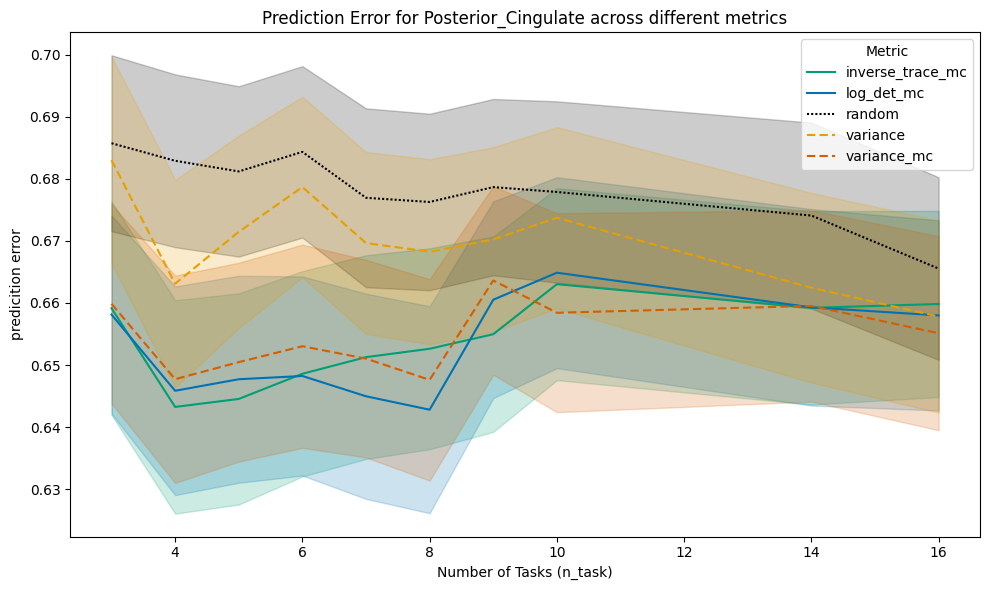

In [19]:
# check unique ROIs
rois = df['roi'].unique()
for roi in rois:
    df_roi = df[df['roi'] == roi]
    D_averaged_across_iter = averaged_df = plot.average_per_subject(df_roi,'cos_err') # lists of subjects are averaged across iterations
    long_df = averaged_df.explode('avg_cos_err_per_subject') # expands the list of subjects into rows for each subject
    long_df['avg_cos_err_per_subject'] = long_df['avg_cos_err_per_subject'].astype(float) # turns each correaltion for each subject into a float


    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=long_df,
        x="n_task",
        y="avg_cos_err_per_subject",
        hue="metric",
        style="metric",
        errorbar='se',
        palette=custom_palette,
        dashes=custom_dashes
    )

    plt.xlabel("Number of Tasks (n_task)")
    plt.ylabel("predicition error")
    plt.title(f"Prediction Error for {roi} across different metrics")
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()